# Семинар 7. Системы нелинейных уравнений

Перед изучением материалов семинара рекомендуем посетить лекцию или посмотреть видеозапись лекции. Ссылки (YouTube): [лекция 7](https://www.youtube.com/live/0UtUfkqH7v8?si=vQNY8K6XPhPpFYag&t=3311) (начало темы), [лекция 8](https://www.youtube.com/live/AfpEHRqNZb8?si=7xUhMmnyyJXUpSKS&t=14) (продолжение). Желательно также предварительно изучить материалы шестого семинара.

Предполагается, что читатель знает

* классификацию методов численного решения нелинейных уравнений,
* суть метода простых итераций и метода Ньютона решения нелинейных уравнений,
* понятие метрического пространства и его связь с понятием нормированного пространства,
* определение полного метрического пространства,
* определения и примеры векторных и матричных норм,
* теорему об эквивалентности норм в $\mathbb{R}^n$,
* понятие невязки $\textbf{r}^{(s)}$.

# Введение

Предыдущий семинар был посвящён методам численного решения нелинейных уравнений вида

$$f(x)=0.$$

Непрерывная функция $f(x)$ **одной переменной** $x$ предполагалась **скалярной** и **вещественнозначной**. Иначе говоря, предполагалось, что множество значений функции $f(x)$ есть подмножество числовой прямой $\mathbb{R}$.

В настоящем семинаре мы рассмотрим методы численного решения **систем нелинейных уравнений** вида

$$\textbf{f}(\textbf{x})=\textbf{0}.$$

Здесь функция $\textbf{f}(\textbf{x})$ является уже **вектор-функцией векторного аргумента**: $\textbf{x}\in\mathbb{R}^m$, $\textbf{f}\in\mathbb{R}^n$, — причём каждая из компонент вектора $\textbf{f}$ представляет собой (непрерывную) нелинейную функцию компонент вектора $\textbf{x}$. Число уравнений $n$ и количество неизвестных $m$, вообще говоря, могут и не совпадать. Мы ограничимся рассмотрением наиболее распространённого случая $n=m$.

Как известно из прошлого семинара, методы решения нелинейных уравнений делятся на одноточечные и двухточечные (вообще говоря, многоточечные), причём **большинство двухточечных методов основано на последовательном "стягивании" исходного отрезка** $[a,b]$ **локализации** корня $x=\xi$. В многомерном случае понятие отрезка локализации следует заменить более общим понятием **области локализации** $\Omega\subset\mathbb{R}^m$ решения $\textbf{x}=\textbf{u}$ системы нелинейных уравнений. Поскольку $\Omega$ представляет собой множество в многомерном пространстве, построить какой-либо алгоритм его "уменьшения" (в смысле заранее выбранной меры) затруднительно. В связи с этим для численного решения систем нелинейных уравнений, как правило, предлагают только одноточечные методы. Как и в случае одного уравнения, перед применением таких методов требуется предварительно локализовать корень для удачного выбора начального приближения $\textbf{x}^{(0)}$.

Мы рассмотрим два метода решения систем нелинейных уравнений: метод простых итераций (МПИ) и метод Ньютона. Они обобщают соответствующие методы решения одного нелинейного уравнения, изучавшиеся на прошлом семинаре.

# Метод простых итераций

Суть этого метода — та же, что и в случае МПИ, применяемого для решения одного нелинейного уравнения. Система нелинейных уравнений

$$\textbf{f}(\textbf{x})=\textbf{0}$$

некоторыми равносильными преобразованиями приводится к виду

$$\textbf{x}=\boldsymbol{\varphi}(\textbf{x}),$$

после чего организуется итерационный процесс

$$\textbf{x}^{(s+1)}=\boldsymbol{\varphi}\big(\textbf{x}^{(s)}\big),\quad s=0,\,1,\,2,\,\dots\,.$$

Очевидно, что точное решение $\textbf{x}=\textbf{u}$ системы $\textbf{f}(\textbf{x})=\textbf{0}$ представляет собой **неподвижную точку** функции (отображения) $\boldsymbol{\varphi}$:

$$\textbf{u}=\boldsymbol{\varphi}(\textbf{u}).$$

Произвольное отображение $\boldsymbol{\varphi}$ может иметь несколько неподвижных точек или не иметь их вовсе. При организации МПИ нас интересуют лишь такие отображения $\boldsymbol{\varphi}$, которые имеют **единственную неподвижную точку в области $\Omega$ локализации решения $\textbf{x}=\textbf{u}$**  — именно к ней должна сходиться последовательность приближений $\textbf{x}^{(s)}$.

Достаточное условие существования и единственности неподвижной точки отображения $\boldsymbol{\varphi}$ даётся одной из важнейших теорем функционального анализа — **принципом сжимающих отображений**. Приведём её формулировку и доказательство (в общем виде — для произвольного **полного** метрического пространства). Предварительно напомним определение сжимающего отображения.

**Определение 1.** Отображение $F$ метрического пространства $(M,\rho)$ в себя называется *сжимающим*, если для любых $z_1,z_2\in M$ имеет место неравенство

$$\rho(Fz_1,Fz_2)\leq q\cdot\rho(z_1,z_2),$$

в котором $q\in (0,1)$ — фиксированное (для данного отображения $F$) число, а через $Fz$ обозначен образ элемента (точки) $z$ при действии на него отображения $F$.

**Теорема 1 (принцип сжимающих отображений).** *Сжимающее* отображение $F$ *полного* метрического пространства $(M,\rho)$ в себя имеет неподвижную точку, и притом *единственную*.

**Доказательство.** Пусть $z_0\in M$ — произвольный элемент (точка) метрического пространства $(M,\rho)$. Построим последовательность точек

$$z_1=Fz_0,\quad z_2=Fz_1=F^2z_0,\quad\dots,\quad z_s=Fz_{s-1}=F^sz_0,\quad\dots\quad.$$

Заметим, что в силу определения сжимающего отображения $F$ имеет место цепочка неравенств

$$\rho(z_s,z_{s+1})=\rho(F^sz_0,F^{s+1}z_{0})\leq q\cdot\rho(F^{s-1}z_0,F^{s}z_{0})\leq\dots\leq q^s\cdot\rho(z_0,z_{1}).$$

Далее,

$$\rho(z_s,z_{s+r})\leq \sum\limits_{p=0}^{r-1}\rho(z_{s+p},z_{s+p+1})\leq \sum\limits_{p=0}^{r-1}q^{s+p}\cdot \rho(z_{0},z_{1})\leq q^s\cdot\rho(z_{0},z_{1})\cdot\sum\limits_{p=0}^{\infty}q^{p}=\frac{q^s}{1-q}\cdot\rho(z_{0},z_{1}).$$

Здесь первый переход основан на неравенстве треугольника, второй — на выведенном выше неравенстве $\rho(z_s,z_{s+1})\leq q^s\cdot\rho(z_0,z_{1})$.

Поскольку $q\in (0,1)$, $\lim_\limits{s\to\infty}q^s=0$, так что $\lim_\limits{s\to\infty}\rho(z_s,z_{s+r})=0$, т.е. последовательность точек $z_s$ фундаментальна. В силу полноты метрического пространства отсюда следует, что существует $\lim_\limits{s\to\infty} z_s\equiv z$.

Покажем, что $z$ — неподвижная точка отображения $F$, т.е. $Fz=z$. Для этого заметим, что

$$\rho(Fz,z_s)=\rho(Fz,Fz_{s-1})\leq q\cdot\rho(z,z_{s-1}).$$

Поскольку $\lim_\limits{s\to\infty}\rho(z,z_{s-1})=0$ (в силу того, что $z$ — предел последовательности $z_s$), то и $\lim_\limits{s\to\infty}\rho(Fz,z_{s})=0$, или, другими словами, $\lim_\limits{s\to\infty} z_s=Fz$. Но предел последовательности $z_s$ единственен, так что действительно $Fz=z$, т.е. $z$ — неподвижная точка отображения $F$.

Остаётся доказать единственность построенной неподвижной точки. Мы предоставляем это читателю.

**Упражнение.** Завершите доказательство теоремы 1, показав единственность неподвижной точки $z$ сжимающего отображения $F$ полного метрического пространства $(M,\rho)$ в себя.

*Указание.* Предположите противное, воспользуйтесь определением сжимающего отображения и придите к противоречию с условием $q<1$.

Отметим, что из неравенства

$$\rho(z_s,z_{s+r})\leq\frac{q^s}{1-q}\cdot\rho(z_{0},z_{1}),$$

полученного в ходе доказательства теоремы 1, путём предельного перехода при $r\to\infty$ следует, что

$$\rho(z_s,z)\leq\frac{q^s}{1-q}\cdot\rho(z_{0},z_{1}).$$



**Упражнение**. Последнее утверждение опирается на **свойство непрерывности** метрики $\rho$: если $\lim\limits_{s\to\infty}v_s=v$, $\lim\limits_{s\to\infty}w_s=w$, то и $\lim\limits_{s\to\infty}\rho(v_s,w_s)=\rho(v,w)$. Докажите это свойство.

*Указание.* Воспользуйтесь "неравенством четырёхугольника"

$$|\rho(a,b)-\rho(c,d)|\leq \rho(a,c)+\rho(b,d),$$

предварительно доказав его (с помощью двух неравенств треугольника для метрики $\rho$). Вывод неравенства нагляден, если воспользоваться его геометрической интерпретацией.

Выше мы вели рассмотрение в общем виде, не конкретизируя метрическое пространство $(M,\rho)$. При решении систем нелинейных уравнений в роли множества $M$ выступает пространство $\mathbb{R}^n$. Выбором произвольной векторной нормы (см. семинар 3) это пространство превращается в **нормированное пространство**, а любое нормированное пространство является, как известно, метрическим пространством с **индуцированной метрикой**

$$\rho(\textbf{x},\textbf{y})=||\textbf{x}-\textbf{y}||.$$

Подчеркнём, что **обратное утверждение неверно: не во всяком метрическом пространстве можно определить норму**.

Легко доказать, что метрическое пространство $(\mathbb{R}^n,\rho_3)$ с метрикой

$$\rho_3(\textbf{x},\textbf{y})=||\textbf{x}-\textbf{y}||_3=\sqrt{(\textbf{x}-\textbf{y}, \textbf{x}-\textbf{y})}=\bigg(\sum\limits_{i=1}^n(x_i-y_i)^2\bigg)^{1/2},$$

индуцированной евклидовой нормой, является полным. Очевидно также, что в силу эквивалентности норм в $\mathbb{R}^n$ (см. семинар 3) это пространство будет полным относительно любой другой метрики, **индуцированной некоторой векторной нормой** (например, нормами $||\cdot||_1$ или $||\cdot||_2$). Не следует, однако, думать, что пространство $\mathbb{R}^n$ полно относительно произвольной метрики: полнота может не иметь места, если выбрана метрика, не индуцированная какой-либо векторной нормой. Так, в случае $n=1$ можно взять в качестве метрики функцию

$$\rho(x,y)=|\text{arctg}\,x-\text{arctg}\,y|.$$

Пространство $\mathbb{R}$ с такой метрикой не является полным: например, последовательность $x_k=k$ фундаментальна по выбранной метрике, но не имеет (по ней же) предела в $\mathbb{R}$ (т.е. критерий Коши не выполняется — полнота отсутствует).

**Упражнение.** Проверьте последнее утверждение, предварительно доказав, что предложенная функция $\rho(x,y)$ является метрикой.

*Указание.* Начните с доказательства того, что любая функция $\rho(x,y)=|\mathcal{F}(x)-\mathcal{F}(y)|$, где $\mathcal{F}$ — **инъективное** отображение $\mathbb{R}$ в себя, является метрикой на $\mathbb{R}$.

Вообще говоря, все **конечномерные евклидовы** пространства являются полными по метрике, индуцированной евклидовой нормой (т.е. нормой, порождённой заданным в пространстве скалярным произведением). Нормированные пространства, полные по метрике, индуцированной нормой, называются **банаховыми пространствами**, а евклидовы пространства, полные по метрике, порождённой скалярным произведением, называются **гильбертовыми пространствами**. Таким образом, **все конечномерные евклидовы пространства** (в том числе и $\mathbb{R}^n$) **являются гильбертовыми** (а любое гильбертово пространство банахово).

Итак, "переводя на язык норм" теорему 1 и ее следствие (см. выше), получаем следующее утверждение.

**Теорема 2.** Пусть вектор-функция $\boldsymbol{\varphi}:\mathbb{R}^n\to \mathbb{R}^n$ такова, что для любых $\textbf{x},\textbf{y}\in \mathbb{R}^n$ справедливо неравенство

$$||\boldsymbol{\varphi}(\textbf{x})-\boldsymbol{\varphi}(\textbf{y})||\leq q\cdot||\textbf{x}-\textbf{y}||,$$

в котором $q\in(0,1)$, а $||\cdot||$ — произвольная векторная норма. Тогда метод простых итераций

$$\textbf{x}^{(s+1)}=\boldsymbol{\varphi}\big(\textbf{x}^{(s)}\big),\quad s=0,\,1,\,2,\,\dots$$

сходится к решению $\textbf{x}=\textbf{u}$ системы $\textbf{x}=\boldsymbol{\varphi}(\textbf{x})$ от любого начального приближения $\textbf{x}^{(0)}$, причём справедлива следующая оценка погрешности:

$$||\textbf{u}-\textbf{x}^{(s)}||\leq \frac{q^s}{1-q}\cdot||\textbf{x}^{(0)}-\textbf{x}^{(1)}||.$$

Эта теорема неконструктивна, поскольку входящее в неё неравенство (многомерный аналог условия Липшица — см. семинар 6) затруднительно проверить на практике. Однако известно, что условие

$$||\boldsymbol{\varphi}(\textbf{x})-\boldsymbol{\varphi}(\textbf{y})||\leq q\cdot||\textbf{x}-\textbf{y}||$$

следует из ограниченности (с константой $q$) нормы матрицы Якоби функции $\boldsymbol{\varphi}$. Чтобы сформулировать соответствующую теорему, необходимо вспомнить определение выпуклой области.

**Определение 2.** Область $\Omega\subset\mathbb{R}^n$ называется *выпуклой*, если принадлежность этой области любых двух точек $\textbf{a}$ и $\textbf{b}$ влечёт принадлежность той же области точек

$$\textbf{c}_\tau=\textbf{a}+\tau(\textbf{b}-\textbf{a}),\quad\tau\in[0,1].$$

Далее мы предполагаем, что в пространстве $\text{Mat}_{n\times n}(\mathbb{R})$ зафиксирована норма, подчинённая выбранной в $\mathbb{R}^n$ векторной норме (см. семинар 3).

**Теорема 3.** Пусть компоненты $\varphi_i=\varphi_i(\textbf{x})$ вектор-функции $\boldsymbol{\varphi}=\boldsymbol{\varphi}(\textbf{x})$ имеют *равномерно непрерывные* производные в *выпуклой* области $\Omega\subset\mathbb{R}^n$, а матрица Якоби $\textbf{J}_\boldsymbol{\varphi}$ функции $\boldsymbol{\varphi}$ удовлетворяет (в той же области $\Omega$) условию

$$||\textbf{J}_\boldsymbol{\varphi}||\leq q<1.$$

Тогда для любых $\textbf{x},\textbf{y}\in\Omega$ справедливо неравенство

$$||\boldsymbol{\varphi}(\textbf{x})-\boldsymbol{\varphi}(\textbf{y})||\leq q\cdot||\textbf{x}-\textbf{y}||.$$

Подчеркнём, что под матрицей Якоби в теореме 3 понимается (как и в курсе анализа) матрица частных производных

$$\textbf{J}_\boldsymbol{\varphi}=\begin{pmatrix}
     \displaystyle\frac{\partial\varphi_i}{\partial x_j}
  \end{pmatrix}=
  \begin{pmatrix}
     \displaystyle\frac{\partial\varphi_1}{\partial x_1} & \displaystyle\frac{\partial\varphi_1}{\partial x_2} & \dots & \displaystyle\frac{\partial\varphi_1}{\partial x_n} \\
     \displaystyle\frac{\partial\varphi_2}{\partial x_1} & \displaystyle\frac{\partial\varphi_2}{\partial x_2} & \dots & \displaystyle\frac{\partial\varphi_2}{\partial x_n} \\
     \vdots & \vdots & \ddots & \vdots \\
     \displaystyle\frac{\partial\varphi_n}{\partial x_1} & \displaystyle\frac{\partial\varphi_n}{\partial x_2} & \dots & \displaystyle\frac{\partial\varphi_n}{\partial x_n}
  \end{pmatrix}.$$

Отметим, что не следует называть матрицу $\textbf{J}_\boldsymbol{\varphi}$ якобианом: якобианом называется её определитель $\det\textbf{J}_\boldsymbol{\varphi}$, но не сама матрица.

Объединяя утверждения теорем 2 и 3, получаем достаточное условие сходимости МПИ.

**Теорема 4 (достаточное условие сходимости МПИ).** Пусть для решения системы нелинейных уравнений $\textbf{f}(\textbf{x})=\textbf{0}$, рассматриваемой при $\textbf{x}\in\Omega$, где $\Omega\subset\mathbb{R}^n$ — *выпуклая* область, предложен метод простых итераций

$$\textbf{x}^{(s+1)}=\boldsymbol{\varphi}\big(\textbf{x}^{(s)}\big),\quad s=0,\,1,\,2,\,\dots\,,$$

причём компоненты $\varphi_i=\varphi_i(\textbf{x})$ вектор-функции $\boldsymbol{\varphi}=\boldsymbol{\varphi}(\textbf{x})$ имеют *равномерно непрерывные* производные в $\Omega$, а матрица Якоби функции $\boldsymbol{\varphi}$ удовлетворяет неравенству

$$||\textbf{J}_\boldsymbol{\varphi}||\leq q<1.$$

Тогда предложенный метод простых итераций сходится к точному решению $\textbf{x}=\textbf{u}$ системы $\textbf{f}(\textbf{x})=\textbf{0}$ от любого начального приближения $\textbf{x}^{(0)}\in\Omega$, а для погрешности приближённого решения $\textbf{x}^{(s)}$ справедлива оценка

$$||\textbf{u}-\textbf{x}^{(s)}||\leq \frac{q^s}{1-q}\cdot||\textbf{x}^{(0)}-\textbf{x}^{(1)}||.$$

## Задача 1

Известно, что одно из решений системы нелинейных уравнений

$$
  \begin{cases}
    x^3 + y^2 - 6x + 3 = 0,\\
    x^3 - y^2 - 6y + 2 = 0
  \end{cases}
$$

лежит в единичном круге на плоскости $\mathbb{R}^2$. Предложить МПИ для приближённого нахождения этого решения.

**Решение.** Перепишем систему в эквивалентном виде

$$
  \begin{cases}
    x = \displaystyle\frac{x^3 + y^2 + 3}{6},\\[0.2cm]
    y = \displaystyle\frac{x^3 - y^2 + 2}{6}
  \end{cases}
$$

и организуем следующий итерационный процесс:

$$\textbf{x}^{(s+1)}=\boldsymbol{\varphi}\big(\textbf{x}^{(s)}\big),\quad \boldsymbol{\varphi}=
  \begin{pmatrix}
     \displaystyle\frac{x_1^3 + x_2^2 + 3}{6} & \displaystyle\frac{x_1^3 - x_2^2 + 2}{6}
  \end{pmatrix}^\text{T}.$$

Проверим достаточное условие сходимости предложенного МПИ. Выпишем матрицу Якоби функции $\boldsymbol{\varphi}$:

$$\textbf{J}_\boldsymbol{\varphi}=
  \begin{pmatrix}
    \displaystyle\frac{x_1^2}{2} & \displaystyle\frac{x_2}{3}\\[0.1cm]
    \displaystyle\frac{x_1^2}{2} & -\displaystyle\frac{x_2}{3}
  \end{pmatrix}.$$

Её норма (подчинённая кубической норме в $\mathbb{R}^2$):

$$||\textbf{J}_\boldsymbol{\varphi}||_\text{I}= \frac{x_1^2}{2}+\frac{|x_2|}{3}.$$

Очевидно, что в (замкнутом) единичном круге справедлива оценка

$$||\textbf{J}_\boldsymbol{\varphi}||_\text{I}\leq\frac{1}{2}+\frac{1}{3}=\frac{5}{6}\equiv q<1.$$

Таким образом, достаточное условие сходимости МПИ выполнено, а значит, построенный итерационный процесс можно применить для отыскания решения. В качестве начального приближения можно взять любую точку из единичного круга — например, точку с координатами $x_1^{(0)}=x_2^{(0)}=1/2$.

Применим предложенный МПИ для отыскания корня — напишем реализующую его функцию ```SI_method1_v1```. Непосредственный расчёт очередного приближения вынесем в функцию ```phi_1```:

In [ ]:
import numpy as np

def phi_1(x: np.ndarray):
    return np.array([(x[0]**3 + x[1]**2 + 3) / 6,
                     (x[0]**3 - x[1]**2 + 2) / 6])

def SI_method1_v1(x0: np.ndarray, q: float, eps: float):
    x1 = phi_1(x0) # первую итерацию выполняем вне цикла,
                   # чтобы сделать возможной априорную оценку числа итераций

    s = np.log(eps * (1 - q) / np.linalg.norm(x0 - x1, ord=1)) / np.log(q)
    # s = np.log(eps) / np.log(q) # другой вариант оценки числа итераций
    s = int(np.ceil(s))

    for i in range(s - 1):
        x1 = phi_1(x1)

    return x1, s

В этой программе число итераций метода оценено априорно с помощью неравенства

$$s\geq\ln\bigg(\frac{\varepsilon(1-q)}{||\textbf{x}^{(0)}-\textbf{x}^{(1)}||}\bigg)\Big/\ln{q},$$

следующего из теоремы 4 ($\varepsilon$ — заданная погрешность приближённого решения). Первую итерацию приходится выполнять отдельно (до основного цикла), чтобы сделать возможным расчёт величины $||\textbf{x}^{(0)}-\textbf{x}^{(1)}||$. Можно положить в основу оценки и другое неравенство:

$$s\geq\ln\frac{1}{\varepsilon}\Big/\ln\frac{1}{q}=\ln\varepsilon\Big/\ln q.$$

Оно возникает из требования $q^s\leq\varepsilon$, означающего, что за $s$ итераций погрешность уменьшается в $q^s$ раз (соответственно, если первоначально она была порядка единицы, то через $s$ итераций оценивается величиной $q^s$).

Для второй оценки не требуется предварительно находить итерационную поправку $||\textbf{x}^{(0)}-\textbf{x}^{(1)}||$. Однако и в первом, и во втором неравенствах фигурирует величина $q$, вообще говоря, неизвестная. При запуске программы можно положить $q=5/6$ — это оценка, которую мы установили при решении задачи:

In [ ]:
%time res, s = SI_method1_v1(np.array([1/2, 1/2]), q=5/6, eps=1e-3)

CPU times: user 211 µs, sys: 0 ns, total: 211 µs
Wall time: 215 µs


In [ ]:
x, y = float(res[0]), float(res[1])
(x, y)

(0.5466188405905157, 0.341156300201465)

Для нахождения решения потребовалось совершить около 40 итераций:

In [ ]:
s

41

Нужно иметь в виду, что оценка $q$ через норму матрицы Якоби может оказаться сильно завышенной (кроме того, она зависит от рассматриваемой области $\Omega$ — в данном случае в роли этой области выступает единичный круг). Очевидно, что чем ближе величина $q$ к единице, тем большей окажется оценка на число итераций $s$. Поэтому в некоторых случаях априорное оценивание может давать явно чрезмерное количество итераций.

В приведённом примере $q=5/6$, что ненамного меньше единицы, и число итераций получается сравнительно большим, хотя и приемлемым (при $0,99<q<1$ оценка на $s$ может оказаться куда более значительной). Однако можно показать, что в данном случае выполнение сорока итераций избыточно для отыскания решения с точностью $10^{-3}$.

В самом деле, осуществим подстановку найденных $x$ и $y$ в исходную систему и проверим равенства $f_1(x,y)=0$ и $f_2(x,y)=0$ с помощью уже знакомой нам функции ```np.allclose``` (см. третий семинар):

In [ ]:
np.allclose([x**3 + y**2 - 6*x + 3, x**3 - y**2 - 6*y + 2],
            [0, 0])

True

Напомним, что по умолчанию равенство проверяется с абсолютной точностью $10^{-8}$. Таким образом, в действительности за 40 итераций мы нашли решение не с точностью $10^{-3}$, а с гораздо более высокой точностью (не хуже $10^{-8}$), чего в постановке задачи не требовалось.

Для более детального исследования вычислим норму невязки $\textbf{r}^{(s)}$:

In [ ]:
rs_norm = np.linalg.norm([x**3 + y**2 - 6*x + 3,
                          x**3 - y**2 - 6*y + 2], ord=1)
float(rs_norm)

2.220446049250313e-16

Получившаяся величина имеет порядок ошибок округления. Для сравнения вычислим норму невязки $\textbf{r}^{(0)}$ (учитываем, что выше в качестве начального приближения мы выбрали вектор с координатами $x^{(0)}_1=x^{(0)}_2=1/2$):

In [ ]:
r0_norm = np.linalg.norm([x**3 + y**2 - 6*x + 3 - 1/2,
                          x**3 - y**2 - 6*y + 2 - 1/2], ord=1)
float(r0_norm)

0.9999999999999998

Как видим, за 41 итерацию норма невязки уменьшилась примерно на 16 порядков. Ясно, что достигнутая при этом точность существенно лучше точности $10^{-3}$, которая требовалось при запуске программы. Отметим, что для корректного анализа точности важно вычислять именно отношение норм невязок. На прошлом семинаре мы уже подчёркивали, что критерий остановки итераций, основанный на проверке малости величины $||\textbf{f}||$ (в одномерном случае — величины $|f|$), не может считаться надёжным.

На практике для более точного определения числа итераций оценку на $q$ устанавливают численно (по ходу расчёта) с помощью формулы

$$q=\frac{||\textbf{x}^{(s+1)}-\textbf{x}^{(s)}||}{||\textbf{x}^{(s)}-\textbf{x}^{(s-1)}||}.$$

Нужно только помнить, что этой формулой можно пользоваться **в достаточно малой окрестности решения**. Соответствующий вариант программы (для наглядности включим в него возврат величины $q$ для вывода её на печать):

In [ ]:
def SI_method1_v2(x0: np.ndarray, eps: float):
    # первые две итерации выполняем вне цикла,
    # чтобы сделать возможной оценку q
    x1 = phi_1(x0)
    x2 = phi_1(x1)
    q = np.linalg.norm(x2 - x1, ord=1) / np.linalg.norm(x1 - x0, ord=1)

    s = np.log(eps * (1 - q) / np.linalg.norm(x0 - x1, ord=1)) / np.log(q)
    # s = np.log(eps) / np.log(q) # другой вариант оценки числа итераций
    s = int(np.ceil(s))
    # s = int(np.ceil(s)) + 1 # после округления лучше увеличить число итераций на единицу

    for i in range(s - 2):
        x2 = phi_1(x2)

    return x2, s, q

In [ ]:
%time res, s, q = SI_method1_v2(np.array([1/2, 1/2]), eps=1e-3)

CPU times: user 118 µs, sys: 3 µs, total: 121 µs
Wall time: 123 µs


In [ ]:
x, y = float(res[0]), float(res[1])
(x, y)

(0.5466150837587066, 0.34132051030744753)

На этот раз нам понадобилось всего четыре итерации:

In [ ]:
s

4

Столь резкое сокращение числа итераций (по сравнению с предыдущим вариантом программы) объясняется тем, что в действительности $q < 5/6$; более точная численная оценка дала:

In [ ]:
float(q)

0.20312500000000022

Отметим, что при организации МПИ лучше не только округлять найденное $s$ вверх до ближайшего целого, но и увеличивать его на единицу (как в комментированной строке), иначе можно "не дойти" до требуемой точности:

In [ ]:
np.allclose([x**3 + y**2 - 6*x + 3, x**3 - y**2 - 6*y + 2],
            [0, 0], atol=1e-3)

False

Если в функции ```SI_method1_v2``` раскомментировать строку с увеличением $s$ на единицу, то последняя проверка даст положительный результат — приближённое решение будет удовлетворять системе с требуемой точностью $10^{-3}$.

## Задача 2

Предложить МПИ для отыскания решения системы уравнений

$$
  \begin{cases}
    x^2 + y^2  = 25,\\
    (x+1)^3 - y + 1 = 0,
  \end{cases}
$$

принадлежащего **первому квадранту**.

**Решение.** Из формулировки теоремы 4 ясно, что предлагать какой-либо вариант МПИ следует, вообще говоря, лишь после того, как решение системы локализовано в некоторой области $\Omega$: только после локализации можно проверить выполнение достаточного условия сходимости. Однако на практике удобнее действовать иначе. Поскольку вид области $\Omega$ нас не интересует, значительно легче получить для предложенного МПИ матрицу Якоби $\textbf{J}_\boldsymbol{\varphi}$, а потом попытаться удовлетворить условию $||\textbf{J}_\boldsymbol{\varphi}||\leq q<1$, подобрав (если это возможно) соответствующую область $\Omega$ (разумеется, она должна выбираться так, чтобы ей принадлежало искомое решение). Проиллюстрируем описанный подход.

Перепишем исходную систему следующим образом (знак $y$ выбираем с учётом того, что ищем решение в первом квадранте):

$$\begin{cases}
      x=(y-1)^{1/3}-1,\\
      y=(25-x^2)^{1/2}.
  \end{cases}$$

Соответствующий МПИ имеет вид

$$\textbf{x}^{(s+1)}=\boldsymbol{\varphi}\big(\textbf{x}^{(s)}\big),\quad \boldsymbol{\varphi}=
  \begin{pmatrix}
     (x_2-1)^{1/3}-1 \\
     (25-x_1^2)^{1/2}
  \end{pmatrix}.$$

Матрица Якоби функции $\boldsymbol{\varphi}$:

$$\textbf{J}_\boldsymbol{\varphi}=
  \begin{pmatrix}
    0 & \displaystyle\frac{1}{3}(x_2-1)^{-2/3}\\[0.1cm]
    -x_1(25-x_1^2)^{-1/2} & 0
  \end{pmatrix}.$$

Заметим, что ненулевые элементы этой матрицы оказались функциями одного аргумента: либо аргумента $x_2$, либо аргумента $x_1$ (два аргумента сразу ни в одну функцию не входят). Для удобства введём обозначения:

$$\alpha(x_2)=\frac{1}{3}(x_2-1)^{-2/3},\quad \beta(x_1)=-x_1(25-x_1^2)^{-1/2}.$$

Очевидно, что

$$\lim_\limits{x_2\to 1}\alpha(x_2)=+\infty,\quad \lim_\limits{x_2\to +\infty}\alpha(x_2)=+0.$$

Далее, при $x_2>1$ функция $\alpha$ принимает положительные значения и является убывающей, так как

$$\alpha'(x_2)=-\frac{2}{9}(x_2-1)^{-5/3}<0,\quad\text{если}\quad x_2>1.$$

Кроме того, $\alpha(2)=1/3$. Поэтому можно гарантировать, что

$$0<\alpha(x_2)<1\quad\text{при}\quad x_2>2.$$

Аналогичным образом анализируем функцию $\beta$. Прежде всего, замечаем, что при $x_1>0$ (т.е. в первом квадранте — см. условие задачи) она принимает отрицательные значения, причём

$$\lim_\limits{x_1\to 5}\beta(x_1)=-\infty.$$

Как и функция $\alpha$, функция $\beta$ является убывающей (на всём первом квадранте), поскольку

$$\beta'(x_1)=-(25-x_1^2)^{-1/2}-x_1^2(25-x_1^2)^{-3/2}<0\quad\text{при}\quad x_1>0.$$

Наконец, $\beta(3)=-3/4$, поэтому

$$-\frac{3}{4}<\beta(x_1)<0,\quad\text{если}\quad 0<x_1<3.$$

Установленные неравенства для функций $\alpha$ и $\beta$ позволяют утверждать, что в бесконечной полосе

$$U=\big\{\textbf{x}\in\mathbb{R}^2:\phantom{-}0<x_1<3,\phantom{-}x_2>2\big\}$$

выполнено условие $||\textbf{J}_\boldsymbol{\varphi}||_\text{I}<1$. Перед тем как приступать к вычислениям на компьютере, эту полосу надо "обрезать". Легко видеть, что первое уравнение исходной системы представляет собой уравнение окружности с радиусом $5$ и центром в начале координат. Эта окружность вписана в (замкнутый) квадрат

$$C=\big\{\textbf{x}\in\mathbb{R}^2:\phantom{-}|x_1|\leq5,\phantom{-}|x_2|\leq5\big\},$$

так что искать решение рассматриваемой системы во внешности $\mathbb{R}^2\,\backslash\, C$ этого квадрата явно не имеет смысла (вместе с тем очевидно, что ни одна из четырёх точек, в которых окружность касается сторон квадрата, не является решением системы). Поэтому окончательно требующуюся для реализации МПИ (выпуклую) область $\Omega$ можно определить следующим образом:

$$\Omega=U\cap C=\big\{\textbf{x}\in\mathbb{R}^2:\phantom{-}0<x_1<3,\phantom{-}2<x_2<5\big\}.$$

Итак, для предложенного МПИ нам удалось подобрать выпуклую область $\Omega$ (она представляет собой открытый квадрат со стороной $3$), в которой выполнено условие $||\textbf{J}_\boldsymbol{\varphi}||_\text{I}<1$. Таким образом, этот МПИ сходится к искомому решению (если, конечно, оно принадлежит $\Omega$). В качестве начального приближения $\textbf{x}^{(0)}$ можно взять любую точку из множества $\Omega$ — например, точку с координатами $x_1^{(0)}=3/2$, $x_2^{(0)}=7/2$ (это центр квадрата $\Omega$).

Чтобы завершить обоснование предложенного МПИ, нам осталось убедиться, что найденная область $\Omega$ содержит решение системы. В данном случае это проще всего сделать графически. Отобразим на графике область $\Omega$ и кривые, заданные уравнениями системы (здесь это сделать легко, поскольку переходом к равносильной системе нам удалось выразить $x$ как **явную** функцию $y$ и $y$ как **явную** функцию $x$, что возможно не всегда):

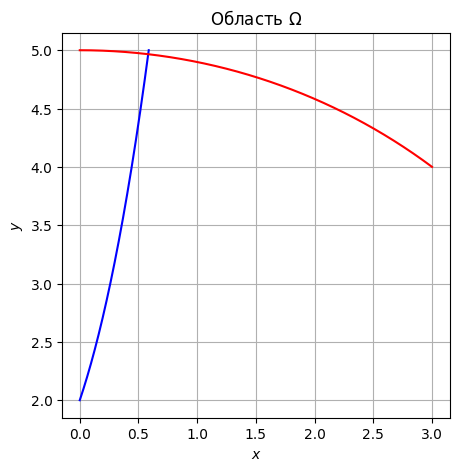

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def graph():
    x_grid = np.linspace(0, 3, 1000)
    y_grid = np.linspace(2, 5, 1000)

    x_sys = np.vectorize(lambda y: (y - 1)**(1/3) - 1)
    y_sys = np.vectorize(lambda x: (25 - x**2)**(1/2))

    x = x_sys(y_grid)
    y = y_sys(x_grid)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(x, y_grid, color='blue')
    ax.plot(x_grid, y, color='red')

    ax.set_title("Область $\\Omega$")

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

    ax.grid()

    plt.show()

graph()

Как видим, область $\Omega$ содержит точку пересечения кривых, т.е. является областью локализации искомого решения системы. Значит, рассматриваемый МПИ можно применять для нахождения решения — сходимость последовательности приближений обеспечивается теоремой 4.

Программа, реализующая метод (учитываем все замечания, высказанные при написании программы для предыдущей задачи):

In [ ]:
def phi_2(x: np.ndarray):
    return np.array([(x[1] - 1)**(1/3) - 1,
                     (25 - x[0]**2)**(1/2)])

def SI_method2(x0: np.ndarray, eps: float):
    x1 = phi_2(x0)
    x2 = phi_2(x1)

    q = np.linalg.norm(x2 - x1, ord=1) / np.linalg.norm(x1 - x0, ord=1)

    s = np.log(eps * (1 - q) / np.linalg.norm(x0 - x1, ord=1)) / np.log(q)
    #s = np.log(1 / eps) / np.log(1 / q) # другой вариант оценки числа итераций
    s = int(np.ceil(s)) + 1

    for i in range(s - 2):
        x2 = phi_2(x2)

    return x2, s

In [ ]:
%time res, s = SI_method2(np.array([3/2, 7/2]), eps=1e-16)

CPU times: user 149 µs, sys: 4 µs, total: 153 µs
Wall time: 155 µs


In [ ]:
x, y = float(res[0]), float(res[1])
(x, y)

(0.5828785112061401, 4.9659090447947305)

Для достижения точности $10^{-16}$ потребовалось всего около 20 итераций:

In [ ]:
s

23

Проверка:

In [ ]:
np.allclose([x**2 + y**2, (x + 1)**3 - y + 1],
            [25, 0], atol=1e-16)

True

В заключение разбора этой задачи подчеркнём, что обоснование предложенного МПИ **обязательно** должно включать два этапа:

* подбор при помощи **аналитического** (или полуаналитического) **анализа** выпуклой области, в которой выполняется условие $||\textbf{J}_\boldsymbol{\varphi}||<1$,
* проверку того, что найденная область является **областью локализации решения** (в случае системы из двух уравнений проверку проще всего осуществить графически).

В некоторых задачах удобнее выполнять эти этапы в обратном порядке, отталкиваясь от примерной локализации решения (установленной визуально по графику) и "подгоняя" границы области так, чтобы в ней выполнялось условие $||\textbf{J}_\boldsymbol{\varphi}||<1$. Так или иначе, оба этапа должны присутствовать. Нельзя считать, как это иногда делают, что достаточное условие сходимости МПИ выполнено и гарантирует сходимость метода, если в какой-то одной точке вблизи корня (подобранной случайно из графика) норма матрицы Якоби оказалась строго меньше единицы — это условие, рассматриваемое без дополнительного анализа, ещё ничего не даёт. Его можно использовать на практике для подбора начального приближения, если планируется запускать МПИ **наудачу**, без строгой проверки достаточного условия сходимости. Однако **обоснование** МПИ должно осуществляться так, как это было показано выше.

## Задача 3

Предложить МПИ для отыскания решения системы уравнений

$$
  \begin{cases}
    x + 3 \lg x - y^2 = 0,\\
    2x^2 -xy - 5x + 1=0,
  \end{cases}
$$

принадлежащего **первому квадранту**.

**Решение.** Будем действовать так же, как и при решении предыдущей задачи. Рассмотрим два варианта МПИ.

*Вариант A.* Проще всего выразить $x$ из первого уравнения системы, а $y$ — из второго:

$$
  \begin{cases}
    x = -3 \lg x + y^2,\\[0.2cm]
    y = 2x - 5 + \dfrac{1}{x}.
  \end{cases}
$$

Организуем МПИ:

$$\textbf{x}^{(s+1)}=\boldsymbol{\varphi}_\text{A}\big(\textbf{x}^{(s)}\big),\quad \boldsymbol{\varphi}_\text{A}=
  \begin{pmatrix}
     -3\lg x_1 + x_2^2 & \displaystyle 2x_1-5+\frac{1}{x_1}
  \end{pmatrix}^\text{T}.$$

Матрица Якоби функции $\boldsymbol{\varphi}_\text{A}$:

$$\textbf{J}_{\boldsymbol{\varphi}_\text{A}}=
  \begin{pmatrix}
  -\displaystyle\frac{3}{x_1\ln 10} & 2x_2 \\[0.2cm]
  2-\displaystyle\frac{1}{x_1^2} & 0
  \end{pmatrix}.$$

Как и в предыдущей задаче, каждый из ненулевых элементов матрицы Якоби оказался функцией одной переменной:

$$\alpha(x_1)=-\frac{3}{x_1\ln 10},\quad \beta(x_1)=2-\frac{1}{x_1^2},\quad \gamma(x_2)=2x_2.$$

В данном случае представляется удобным использовать вторую матричную норму $||\cdot||_\text{II}$, поскольку

$$||\textbf{J}_{\boldsymbol{\varphi}_\text{A}}||_\text{II}=\max\Big[\big|\alpha(x_1)\big|+\big|\beta(x_1)\big|,\big|\gamma(x_2)\big|\Big],$$

т.е. функции одного аргумента "собираются" в одну сумму, а функция другого аргумента остаётся обособленной. В первом квадранте

$$\big|\alpha(x_1)\big|+\big|\beta(x_1)\big|=\frac{3}{x_1\ln 10}+\sqrt{\bigg(2-\displaystyle\frac{1}{x_1^2}\bigg)^2}\equiv\eta(x_1),$$

причём

$$\eta'(x_1)=\frac{2\cdot\text{sign}\big(2-x_1^{-2}\big)}{x_1^3}-\frac{3}{x_1^2\cdot\ln{10}}.$$

Очевидно, что при $0<x_1<1/\sqrt{2}$ каждое из слагаемых, входящих в $\eta'$, оказывается отрицательным. Далее, модуль второго слагаемого больше модуля первого слагаемого при $x_1>2\ln(10)/3$. Поэтому $\eta'<0$ при $0<x_1<1/\sqrt{2}$ и $x_1>2\ln(10)/3$, а значит, при тех же $x_1$ функция $\eta$ убывает. Так как

$$\lim\limits_{x_1\to\infty}\eta(x_1)=2,\quad \eta\bigg(\frac{1}{\sqrt{2}}\bigg)=\frac{3\sqrt{2}}{\ln{10}}>1,$$

можно гарантировать, что вне интервала $1/\sqrt{2}<x_1<2\ln{10}/3$ выполнено условие $\eta>1$. При $x_1$, принадлежащих этому интервалу, первое слагаемое в $\eta'$ положительно, а его модуль больше модуля второго слагаемого, так что $\eta'>0$ и функция $\eta$ возрастает. В силу того, что, как уже отмечалось, $\eta(1/\sqrt{2})>1$, внутри указанного интервала тоже имеет место неравенство $\eta>1$.

Таким образом, $\eta>1$ при всех $x_1>0$, откуда следует, что в первом квадранте условию $||\textbf{J}_{\boldsymbol{\varphi}_\text{A}}||_\text{II}<1$ удовлетворить нельзя. К тому же выводу можно было бы прийти и без изложенных выкладок, просто построив график функции $\eta$.


Если же вместо "удобной" нормы $||\cdot||_\text{II}$ выбрать всё-таки норму $||\cdot||_\text{I}$, то и в этом случае окажется, что условие  $||\textbf{J}_{\boldsymbol{\varphi}_\text{A}}||_\text{I}<1$ невыполнимо. В самом деле,

$$||\textbf{J}_{\boldsymbol{\varphi}_\text{A}}||_\text{I}=\max\Big[\big|\alpha(x_1)\big|+\big|\gamma(x_2)\big|,\big|\beta(x_1)\big|\Big].$$

Решая неравенство $|\beta(x_1)|<1$, получаем условие на $x_1$:

$$\frac{1}{\sqrt{3}}<x_1<1.$$

Для удобства снова обозначим

$$\eta(x_1,x_2)=\big|\alpha(x_1)\big|+\big|\gamma(x_2)\big|=\frac{3}{x_1\ln 10}+2x_2>0$$

(мы вновь учли, что рассматривается первый квадрант). Заметим, что на интервале $1/\sqrt{3}<x_1<1$ первое из двух входящих в $\eta$ слагаемых строго больше единицы, поскольку $3/\ln10>1$ (а само это слагаемое убывает при положительных $x_1$). Значит, при любых положительных $x_2$ будем иметь $\eta>1$. Отсюда следует, что совместить требования $\eta<1$ и $|\beta|<1$ в первом квадранте не удаётся, т.е. условию $||\textbf{J}_{\boldsymbol{\varphi}_\text{A}}||_\text{I}<1$ удовлетворить нельзя.

Очевидно, что попытки аналитически рассмотреть условие $||\textbf{J}_{\boldsymbol{\varphi}_\text{A}}||_\text{III}<1$, в котором фигурирует третья из основных матричных норм, приведут к очень сложным выкладкам (понадобится рассматривать спектр матрицы $\textbf{J}_{\boldsymbol{\varphi}_\text{A}}^\dagger\textbf{J}_{\boldsymbol{\varphi}_\text{A}}$ в зависимости от параметров $x_1$ и $x_2$). Эту норму, как правило, лучше вообще не использовать в подобных задачах. Неудача с первыми двумя нормами заставляет отказаться от предложенного варианта МПИ.

*Вариант B.* Преобразуем исходную систему более сложным способом: выразим $y$ из первого уравнения, а $x$ — из второго (знаки снова выбираем с учётом того, что ищем решение из первого квадранта):

$$
  \begin{cases}
    x =\bigg[\displaystyle\frac{1}{2}(xy+5x-1)\bigg]^{1/2},\\[0.2cm]
    y = (x + 3 \lg x)^{1/2}.
  \end{cases}
$$

Имеем МПИ:

$$
  \textbf{x}^{(s+1)}=\boldsymbol{\varphi}_\text{B}\big(\textbf{x}^{(s)}\big),\quad \boldsymbol{\varphi}_\text{B}=
  \begin{pmatrix}
     \bigg[\displaystyle\frac{1}{2}(x_1x_2+5x_1-1)\bigg]^{1/2} & (x_1 + 3 \lg x_1)^{1/2}
  \end{pmatrix}^\text{T}.
$$

До сих пор мы выписывали матрицы Якоби, предполагая, что они находятся вручную. Покажем на примере матрицы $\textbf{J}_{\boldsymbol{\varphi}_\text{B}}$, как их можно находить с помощью уже знакомой нам библиотеки ```sympy```. Для этого в классе ```Matrix``` ([документация](https://docs.sympy.org/latest/tutorials/intro-tutorial/matrices.html)) данной библиотеки существует метод ```jacobian``` ([документация](https://docs.sympy.org/latest/modules/matrices/matrices.html#sympy.matrices.matrixbase.MatrixBase.jacobian); название метода следует понимать как сокращение английского термина "Jacobian matrix", а не как буквальный перевод русского термина "якобиан", служащего названием **определителя** матрицы Якоби):

In [ ]:
from sympy import symbols, Matrix, log

x1, x2, phi = symbols('x_1, x_2, phi')

phi = Matrix(['((x1 * x2 + 5 * x1 - 1) / 2) ** (1/2)',
               '(x1 + 3 * log(x1)/log(10)) ** (1/2)'])

J = phi.jacobian(['x1', 'x2'])
J

Matrix([
[            (x2/4 + 5/4)/sqrt(x1*x2/2 + 5*x1/2 - 1/2), x1/(4*sqrt(x1*x2/2 + 5*x1/2 - 1/2))],
[(1/2 + 3/(2*x1*log(10)))/sqrt(x1 + 3*log(x1)/log(10)),                                   0]])

Как мы знаем из второго семинара, символьные выражения можно упрощать с помощью функции ```simplify``` ([документация](https://docs.sympy.org/latest/modules/simplify/simplify.html)):

In [ ]:
from sympy import simplify

simplify(J)

Matrix([
[                       sqrt(2)*(x2 + 5)/(4*sqrt(x1*x2 + 5*x1 - 1)), sqrt(2)*x1/(4*sqrt(x1*x2 + 5*x1 - 1))],
[(x1*log(10) + 3)/(2*x1*sqrt(x1*log(10) + 3*log(x1))*sqrt(log(10))),                                     0]])

Таким образом,

$$\textbf{J}_{\boldsymbol{\varphi}_\text{B}}=
  \begin{pmatrix}
  \displaystyle\frac{1}{2\sqrt{2}}\cdot\frac{x_2+5}{\sqrt{x_1x_2+5x_1-1}} & \displaystyle\frac{1}{2\sqrt{2}}\cdot\frac{x_1}{\sqrt{x_1x_2+5x_1-1}} \\[0.2cm]
  \displaystyle\frac{x_1+3/\ln{10}}{2x_1\sqrt{x_1+3\lg{x_1}}} & 0
  \end{pmatrix}.$$

Вводим обозначения:

$$\alpha(x_1,x_2)=\frac{1}{2\sqrt{2}}\cdot\frac{x_2+5}{\sqrt{x_1x_2+5x_1-1}},\quad \beta(x_1,x_2)=\displaystyle\frac{1}{2\sqrt{2}}\cdot\frac{x_1}{\sqrt{x_1x_2+5x_1-1}},\quad\gamma(x_1)=\displaystyle\frac{x_1+3/\ln{10}}{2x_1\sqrt{x_1+3\lg{x_1}}}.$$

Очевидно, что здесь удобнее взять норму $||\cdot||_\text{I}$, поскольку

$$||\textbf{J}_{\boldsymbol{\varphi}_\text{B}}||_\text{I}=\max\Big[\big|\alpha(x_1,x_2)\big|+\big|\beta(x_1,x_2)\big|,\big|\gamma(x_1)\big|\Big],$$

причём

$$\big|\alpha(x_1,x_2)\big|+\big|\beta(x_1,x_2)\big|=\frac{1}{2\sqrt{2}}\cdot\frac{x_1+x_2+5}{\sqrt{x_1x_2+5x_1-1}}\equiv\eta(x_1,x_2).$$

Аналитический анализ условия $|\gamma|<1$ в данном случае оказывается довольно громоздким, в чём легко убедиться, рассмотрев, например, выражение для $\gamma'$, которое понадобилось бы при таком анализе (используем функцию ```diff``` из библиотеки ```sympy```, знакомую нам по второму семинару):

In [ ]:
from sympy import diff, sqrt

gamma = ( x1 + 3 / log(10) ) / ( 2 * x1 * sqrt(x1 + 3 * log(x1)/log(10)) )
diff(gamma, x1)

(-1/2 - 3/(2*x_1*log(10)))*(x_1 + 3/log(10))/(2*x_1*(x_1 + 3*log(x_1)/log(10))**(3/2)) + 1/(2*x_1*sqrt(x_1 + 3*log(x_1)/log(10))) - (x_1 + 3/log(10))/(2*x_1**2*sqrt(x_1 + 3*log(x_1)/log(10)))

Значительно проще вместо аналитических выкладок построить график функции $\gamma$. Для этого предварительно решим численно нелинейное уравнение $x_1+3\lg{x_1}=0$, чтобы понять, при каких $x_1$ подкоренное выражение из функции $\gamma$ становится отрицательным. Применим функцию ```root_scalar``` (см. шестой семинар):

In [ ]:
import numpy as np
from scipy.optimize import root_scalar

f = lambda x: x + 3 * np.log10(x)

eps = 1e-8 # для избежания сингулярности логарифма в нуле
root_scalar(f, bracket=(0 + eps, 1))

      converged: True
           flag: converged
 function_calls: 9
     iterations: 8
           root: 0.6209113029036658
         method: brentq

Итак, график функции $\gamma$ имеет смысл рассматривать при $x_1\gtrsim0,63$. Выясним сначала, каков его общий вид:

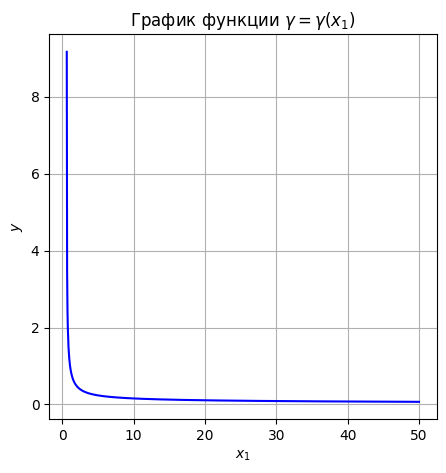

In [ ]:
import matplotlib.pyplot as plt

def graph_gamma(L: float):
    x_grid = np.linspace(0.63, L, 1000)
    gamma = np.vectorize(lambda x:
                         ( x + 3 / np.log(10) ) / ( 2*x * np.sqrt(x + 3 * np.log10(x)) ))

    y = gamma(x_grid)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(x_grid, y, color='blue')

    ax.set_title("График функции $\\gamma=\\gamma(x_1)$")

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$y$")

    ax.grid()

    plt.show()

graph_gamma(50)

"Присмотримся" к графику на отрезке $[0,5]$:

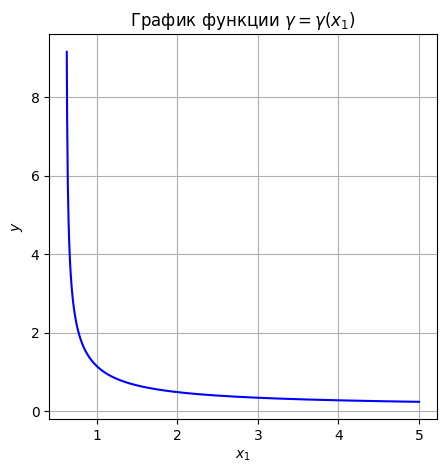

In [ ]:
graph_gamma(5)

Принимая во внимание эти графики, а также то, что

$$\lim_\limits{x_1\to\infty}\gamma(x_1)=\lim_\limits{x_1\to\infty}\frac{1+3/(x_1\ln10)}{2\sqrt{x_1+3\lg x_1}}=0,$$

приходим к выводу: $|\gamma|<1$ при $x_1>2$.

Аналитический подбор области, в которой $\eta(x_1,x_2)<1$, тоже затруднителен и в силу громоздкого вида функции $\eta$, и в силу её зависимости от двух переменных сразу. Поэтому здесь мы тоже воспользуемся графиком, правда, в виде **тепловой карты** (на таком графике значения $\eta$ в точках плоскости $(x_1,x_2)$ отображаются цветом):

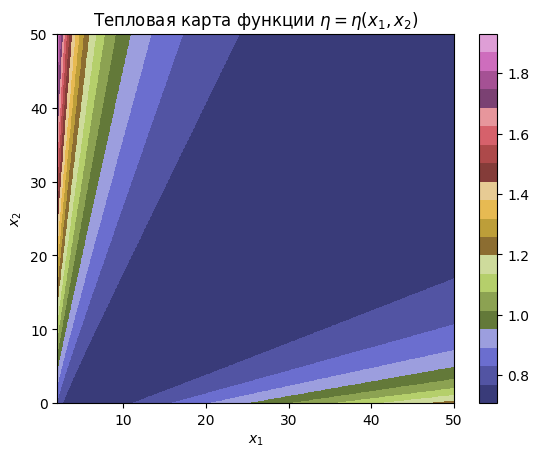

In [ ]:
def graph_eta(L1: float, L2: float):
    x1, x2 = np.meshgrid(np.linspace(2, L1, 1000),
                         np.linspace(0, L2, 1000))
    eta = (x1 + x2 + 5) / np.sqrt(x1*x2 + 5*x1 - 1) / (2*np.sqrt(2))
    eta_min, eta_max = np.min(eta), np.max(eta)

    fig, ax = plt.subplots()
    pcolormesh = ax.pcolormesh(x1, x2, eta, cmap='tab20b', vmin=eta_min, vmax=eta_max)
    ax.axis([x1.min(), x1.max(), x2.min(), x2.max()])
    plt.colorbar(pcolormesh, ax=ax)

    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title("Тепловая карта функции $\\eta=\\eta(x_1,x_2)$")

    plt.show()

graph_eta(L1=50, L2=50)

"Присмотримся" к области вблизи начала отсчёта:

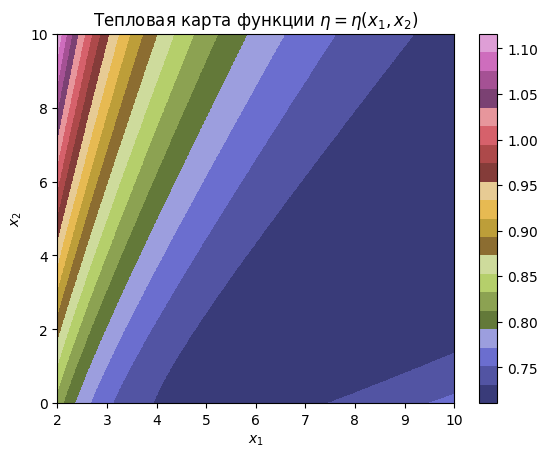

In [ ]:
graph_eta(L1=10, L2=10)

Здесь уже учтено, что $x_1>2$ для выполнения условия $|\gamma|<1$. Из тепловых карт видно, что $\eta<1$, скажем, при $2<x_1<10$ и $0<x_2<4$. Другими словами, в качестве искомой области можно взять множество

$$\Omega=\big\{\textbf{x}\in\mathbb{R}^2:\phantom{-}2<x_1<10,\phantom{-}0<x_2<4\big\}.$$

Итак, в (выпуклой) области $\Omega$ выполняется условие $||\textbf{J}_{\boldsymbol{\varphi}_\text{B}}||_\text{I}<1$. Остаётся только проверить, что эта область содержит корень. Снова прибегаем к графику — отображаем область и кривые, задаваемые уравнениями рассматриваемой системы. В отличие от предыдущей задачи, в данном случае получить **явные** функции $x=x(y)$ и $y=y(x)$ для построения графиков не удаётся и приходится прибегать к искусственным приёмам:

In [ ]:
from sklearn.utils.extmath import cartesian

def curve(f, x_lim: tuple, y_lim: tuple):
    x = np.linspace(x_lim[0], x_lim[1], 1000)
    y = np.linspace(y_lim[0], y_lim[1], 1000)
    points = cartesian([x, y])

    eps = 1e-2 # регулирует толщину контура
    mask = (np.apply_along_axis(f, 1, points) <= 0 + eps) & (np.apply_along_axis(f, 1, points) >= 0 - eps)
    filtered_points = points[mask]

    return filtered_points[:, 0], filtered_points[:, 1]

Функция ```curve```, принимая на вход левую часть уравнения кривой вида $f(\textbf{x})=0$, создаёт сетки по координатам $x$ и $y$ ($10^3$ узлов в каждой), а затем составляет **декартово произведение** из их узлов (с помощью функции ```cartesian``` из модуля ```utils.extmath``` библиотеки ```sklearn```; к сожалению, в официальной документации эта функция не значится). Так получается массив из координат точек (в количестве $10^3\cdot10^3=10^6$), равномерно покрывающих заданную область. Далее этот массив **отфильтровывается с допуском** ```eps```, причём в роли **маски для фильтрации** выступает функция, определяющая кривую. Иначе говоря, из всех точек выбираются лишь те, которые удовлетворяют равенству $f(\textbf{x})=0$ с погрешностью, задаваемой параметром ```eps``` (визуально это влияет на толщину контура). Похожую идею мы уже реализовывали на третьем семинаре, когда строили единичные сферы на плоскости в различных $p$-нормах. Правда, в прошлой демонстрации точки выбирались случайным образом; здесь же воспользоваться генератором случайных чисел нельзя — на графике не получится линий (вместо этого отобразятся лишь отдельные точки) из-за того, что вероятность удовлетворить произвольному нелинейному уравнению $f(\textbf{x})=0$ окажется слишком малой.

Функция для непосредственного построения графика:

In [ ]:
def graph_sys(f1, f2, x_lim: tuple, y_lim: tuple):
    fig, ax = plt.subplots(figsize=(5, 5))

    x1, y1 = curve(f1, x_lim, y_lim)
    x2, y2 = curve(f2, x_lim, y_lim)

    ax.scatter(x1, y1, 0.5, color='blue')
    ax.scatter(x2, y2, 0.5, color='red')

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

    ax.set_xlim([x_lim[0], x_lim[1]])
    ax.set_ylim([y_lim[0], y_lim[1]])

    plt.title("Область $\\Omega$")
    plt.show()

Задаём функции из рассматриваемой системы и строим график:

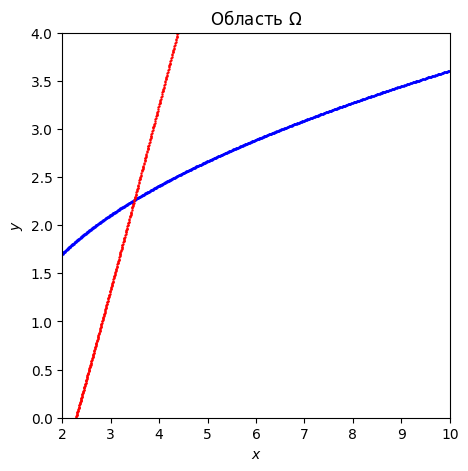

In [ ]:
def f1(x):
    return x[0] + 3 * np.log10(x[0]) - x[1]**2

def f2(x):
    return 2 * x[0]**2 - x[0] * x[1] - 5 * x[0] + 1

graph_sys(f1, f2, x_lim=(2, 10), y_lim=(0, 4)) # исполняется 17 секунд

Как видим, подобранная область содержит корень. Значит, предложенный МПИ можно применять — он гарантированно сойдётся к корню в силу теоремы 4. В качестве начального приближения можно взять любой вектор $\textbf{x}^{(0)}\in\Omega$. Например, можно положить $x_1^{(0)}=6$, а $x_2^{(0)}=2$.

Программную реализацию МПИ составим, не пользуясь априорной оценкой числа итераций. Вместо этого на каждой итерации (начиная с третьей), будем проверять малость итерационной поправки:

$$||\textbf{x}^{(s)}-\textbf{x}^{(s-1)}||\leq \varepsilon(1-q).$$

О таком условии остановки итераций мы уже упоминали на третьем семинаре.

Результаты расчёта:

In [ ]:
def phi_3(x: np.ndarray):
    return np.array([np.sqrt((x[0] * x[1] + 5 * x[0] - 1) / 2),
                     np.sqrt(x[0] + 3 * np.log10(x[0]))])

def SI_method3(x0: np.ndarray, eps: float, maxiter: float = 100):
    x1 = phi_3(x0)
    x2 = phi_3(x1)

    q = np.linalg.norm(x2 - x1, ord=1) / np.linalg.norm(x1 - x0, ord=1)

    for i in range(maxiter - 2):
        x1 = x2
        x2 = phi_3(x2)

        if np.linalg.norm(x2 - x1, ord=1) <= eps * (1 - q): break

    return x2, (i + 1) + 2

In [ ]:
%time res, s = SI_method3(np.array([6, 2]), eps=1e-16)

CPU times: user 1.01 ms, sys: 0 ns, total: 1.01 ms
Wall time: 1.02 ms


In [ ]:
x, y = float(res[0]), float(res[1])
(x, y)

(3.4874427876429537, 2.261628630553594)

In [ ]:
s

81

Проверка решения:

In [ ]:
np.allclose([x + 3 * np.log10(x) - y**2, 2 * x**2 - x * y - 5 * x + 1],
            [0, 0], atol=1e-15)

True

Можно заметить, что в данном случае МПИ сходится в окрестности корня довольно медленно. Об этом свидетельствует не только сравнительно большое число выполненных итераций, но и следующее обстоятельство: если при последнем вызове функции ```np.allclose``` заменить значение ```atol=1e-15``` на ```atol=1e-16``` (точность, установленная при запуске процесса), то проверка не будет пройдена. Потеря точности объясняется приближённостью оценки величины $q$, которая в предложенной программе принимается одинаковой для всех итераций и рассчитывается в начале процесса. Вообще говоря, следует всегда помнить, что при решении нелинейных уравнений и их систем с помощью любых итерационных процессах типа МПИ **скорость сходимости невозможно вычислить — её можно только оценить**.

На примере рассмотренной задачи легко убедиться в том, что выкладки, направленные на обоснование сходимости МПИ, даже в сравнительно простых случаях могут оказаться очень пространными и трудоёмкими. Поэтому **на практике сходимость МПИ обычно и не обосновывают**. Вместо этого его запускают от случайно выбранной точки из окрестности решения и проверяют сходимость апостериорно. Таким образом, можно сказать, что теорема 4 представляет в основном теоретический интерес.

В связи со сказанным необходимо также отметить, что с системами нелинейных уравнений часто приходится сталкиваться при решении более сложных задач. Например, в следующем семестре мы будем рассматривать дифференциальные уравнения в частных производных, содержащие нелинейные члены (а также системы таких уравнений). При численном решении соответствующих начальных и краевых задач приходится многократно (на каждом шаге по времени) решать систему нелинейных уравнений. В подобных случаях провести теоретический анализ и проверку условий сходимости используемого метода затруднительно. Во-первых, размерность системы может оказаться довольно большой ($\sim 10^2\div10^6$). Во-вторых, система нелинейных уравнений решается на каждом шаге (т.е. порядка $\sim 10^2\div10^6$ раз) и изменяется при переходе от одного шага к другому. В-третьих, теоретическое исследование сходимости используемого метода в описанных условиях пришлось бы проводить с учётом зависимости от параметров сетки (например, шагов по времени и пространству), поскольку в сложных задачах они могут меняться по ходу расчёта. Всё это делает апостериорную проверку сходимости метода решения системы нелинейных уравнений единственно возможной.

# Метод Ньютона

Этот метод, как и метод Ньютона для решения одного нелинейного уравнения, получается линеаризацией левой части системы $\textbf{f}(\textbf{x})=\textbf{0}$. Мы выпишем сразу его расчётную формулу:

$$\textbf{x}^{(s+1)}=\textbf{x}^{(s)}-\textbf{J}_\textbf{f}^{-1}\big|^{(s)}\cdot\textbf{f}(\textbf{x}^{(s)}).$$

Подчеркнём, что в этой формуле фигурирует матрица Якоби $\textbf{J}_\textbf{f}$ **исходной** функции $\textbf{f}$ из левой части системы (в отличие от МПИ, для проверки сходимости которого требуется строить не матрицу Якоби $\textbf{J}_\textbf{f}$, а матрицу Якоби $\textbf{J}_\boldsymbol{\varphi}$).

Существует теорема, дающая достаточное условие сходимости метода Ньютона в случае систем нелинейных уравнений. Однако соответствующее условие имеет довольно сложный вид, и поэтому обычно сходимость метода проверяют расчётом, не пользуясь теоремой.

## Задача 4

Записать расчётную формулу метода Ньютона для численного решения системы уравнений

$$
  \begin{cases}
   x^{10} + y^{10} = 1024,\\
    e^x - e^y = 1.
  \end{cases}
$$

**Решение.** Перепишем систему в виде $\textbf{f}(\textbf{x})=\textbf{0}$:

$$
  \begin{cases}
   x_1^{10} + x_2^{10} - 1024 =0,\\[0.1cm]
    e^{x_1} - e^{x_2} - 1 =0.
  \end{cases}
$$

Средствами библиотеки ```sympy``` найдём матрицу Якоби $\textbf{J}_\textbf{f}$, обратную к ней и составим произведение $\textbf{J}^{-1}_\textbf{f}\cdot\textbf{f}(\textbf{x})$:





In [ ]:
from sympy import symbols, Matrix, exp, simplify

x1, x2 = symbols('x_1, x_2')

f = Matrix(['x1**10 + x2**10 - 1024',
            'exp(x1) - exp(x2) - 1'])

J = f.jacobian(['x1', 'x2'])
J.inv() * f

Matrix([
[x2**9*(exp(x1) - exp(x2) - 1)*exp(x1)/(x1**9*exp(x1)*exp(x2) + x2**9*exp(2*x1)) + (x1**10 + x2**10 - 1024)*exp(x1)*exp(x2)/(10*x1**9*exp(x1)*exp(x2) + 10*x2**9*exp(2*x1))],
[                                   -x1**9*(exp(x1) - exp(x2) - 1)/(x1**9*exp(x2) + x2**9*exp(x1)) + (x1**10 + x2**10 - 1024)*exp(x1)/(10*x1**9*exp(x2) + 10*x2**9*exp(x1))]])

Таким образом, расчётная формула метода Ньютона (в покомпонентном виде) выглядит так:

$$x_1^{(s+1)}=\bigg[x_1-\frac{x_2^9\cdot a(x_1,x_2)}{b(x_1,x_2)}-\frac{e^{x_2}\cdot c(x_1,x_2)}{d(x_1,x_2)}\bigg]^{(s)},$$

$$x_2^{(s+1)}=\bigg[x_2-\frac{x_1^9\cdot a(x_1,x_2)}{b(x_1,x_2)}-\frac{e^{x_1}\cdot c(x_1,x_2)}{d(x_1,x_2)}\bigg]^{(s)},$$

где

$$\begin{gather}
  a(x_1,x_2)=e^{x_1}-e^{x_2}-1,\quad b(x_1,x_2)=x_1^9\cdot e^{x_2}+x_2^9\cdot e^{x_1},\\
  c(x_1,x_2)=x_1^{10}+x_2^{10}-1024,\quad d(x_1,x_2)=10x_1^9\cdot e^{{x_2}}+10x_2^9\cdot e^{x_1}.
 \end{gather}$$

Читатель может самостоятельно убедиться (с помощью графика) в том, что рассматриваемая система имеет два решения:

$$\textbf{u}_\text{A}\simeq
  \begin{pmatrix}
    1,930 \\
    1,773
  \end{pmatrix},\quad
  \textbf{u}_\text{B}\simeq
  \begin{pmatrix}
    0,127 \\
    -1,999
  \end{pmatrix}.$$

Найдём, например, второе из них с помощью программы:

In [ ]:
import numpy as np

def Newton_kernel(x: np.ndarray):
    x1, x2 = x[0], x[1]

    a = np.exp(x1) - np.exp(x2) - 1
    b = x1**9 * np.exp(x2) + x2**9 * np.exp(x1)
    c = x1**10 + x2**10 - 1024
    d = 10*x1**9 * np.exp(x2) + 10*x2**9 * np.exp(x1)

    x1_new = x1 - x2**9 * a / b - np.exp(x2) * c / d
    x2_new = x2 - x1**9 * a / b - np.exp(x1) * c / d

    return np.array([x1_new, x2_new])


def Newton_method(x0: np.ndarray, eps: float, maxiter: float = 100):
    x1 = Newton_kernel(x0)
    x2 = Newton_kernel(x1)

    q = np.linalg.norm(x2 - x1, ord=1) / np.linalg.norm(x1 - x0, ord=1)

    for i in range(maxiter - 2):
        x1 = x2
        x2 = Newton_kernel(x2)

        if np.linalg.norm(x2 - x1, ord=1) <= eps * (1 - q): break

    return x2, (i + 1) + 2

In [ ]:
%time res, s = Newton_method(np.array([0.127, -1.999]), eps=1e-8)

CPU times: user 183 µs, sys: 4 µs, total: 187 µs
Wall time: 191 µs


In [ ]:
x, y = float(res[0]), float(res[1])
(x, y)

(0.12692801104299783, -1.999999999999788)

In [ ]:
s

3

Проверка найденного решения:

In [ ]:
np.allclose([x**10 + y**10 - 1024, np.exp(x) - np.exp(y) - 1],
            [0, 0], atol=1e-8)

True

# Решение систем нелинейных уравнений в Python

Модуль ```optimize``` библиотеки ```scipy``` ([документация](https://docs.scipy.org/doc/scipy/reference/optimize.html#root-finding)) предлагет несколько средств для решения систем нелинейных уравнений. Наиболее удобным из них является функция ```root``` ([документация](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root.html)). Мы не будем останавливаться на её подробном описании. Приведём только пример использования (берём систему из задачи 3):

In [ ]:
import numpy as np
from scipy.optimize import root

# функция левой части
def f(x: np.ndarray):
    return [x[0] + 3 * np.log10(x[0]) - x[1]**2,
            2 * x[0]**2 - x[0] * x[1] - 5 * x[0] + 1]

# её матрица Якоби
def jac(x: np.ndarray):
    return [ [1 + 3 / (x[0] * np.log(10)), (-2) * x[1]],
             [4*x[0] - x[1] - 5, -x[0]] ]

%time res = root(f, x0=[6, 2], jac=jac)

CPU times: user 247 µs, sys: 0 ns, total: 247 µs
Wall time: 251 µs


In [ ]:
res

 message: The solution converged.
 success: True
  status: 1
     fun: [ 1.771e-12 -1.051e-11]
       x: [ 3.487e+00  2.262e+00]
  method: hybr
    nfev: 12
    njev: 1
    fjac: [[-1.499e-01 -9.887e-01]
           [ 9.887e-01 -1.499e-01]]
       r: [-7.899e+00  6.334e+00 -3.223e+00]
     qtf: [-1.203e-07 -3.958e-08]

In [ ]:
x, y = res.x
(float(x), float(y))

(3.487442787640844, 2.2616286305525617)

# Практические задачи

## Задача А

Численно решить систему нелинейных уравнений

$$
  \begin{cases}
    20x+y^2+2z^3=6,0420,\\
    x^3+20y+3z^4=4,0273,\\
    x^2+5y^3+20z=2,1300\\
  \end{cases}
$$

с помощью двух методов, **аналогичных методам Якоби и Зейделя решения СЛАУ** (см. пятый семинар). Считать известным, что решение системы принадлежит области

$$\Omega=\big\{\textbf{x}\in\mathbb{R}^3:\phantom{-}0<x_i<1,\phantom{-}i=1,\,2,\,3\big\}.$$

Какой из методов сходится быстрее? Почему?

*Указание.* О методах решения систем нелинейных уравнений, построенных по аналогии с итерационными методами решения СЛАУ, можно прочитать в книге А.А. Самарского и А.В. Гулина (см. список рекомендованной литературы).

# Литература и другие источники

**Видеозаписи:**

1. Вычислительная математика — лекция 7. Лектор — Е.Н. Аристова. [Ссылка](https://www.youtube.com/live/0UtUfkqH7v8?si=vQNY8K6XPhPpFYag&t=3311) (YouTube).

2. Вычислительная математика — лекция 8. Лектор — Е.Н. Аристова. [Ссылка](https://www.youtube.com/live/AfpEHRqNZb8?si=7xUhMmnyyJXUpSKS&t=14) (YouTube).

3. Вычислительная математика — лекция 12. Лектор — А.В. Чикиткин. [Ссылка](https://m.youtube.com/watch?v=t0biwmkGZzg) (YouTube).

**Рекомендуемая литература (с комментариями):**

1.  *В.И. Косарев. 12 лекций по вычислительной математике* — лекция 4, стр. 51—61.

2.  *В.М. Вержбицкий. Численные методы. Линейная алгебра и нелинейные уравнения* — глава 6, стр. 212—244.

3.  *А.А. Амосов, Ю.А. Дубинский, Н.В. Копченова. Вычислительные методы для инженеров* — глава 7, стр. 191—210.

4.  *Б.П. Демидович, И.А. Марон. Основы вычислительной математики* — глава XIII, стр. 450—496.

5.  *Дж. Дэннис, Р. Шнабель. Численные методы безусловной оптимизации и решения нелинейных уравнений.*

6.  *Н.Н. Калиткин, Е.А. Альшина. Численный анализ.* Первый том учебника “Численные методы” (в двух книгах). К теме семинара относится пункт 2.3 главы 2 (стр. 55—59). Разобран только метод Ньютона и его обобщение.

7.  *А.А. Самарский, А.В. Гулин. Численные методы* — четвёртый параграф главы 5 (стр. 207—213). Предложено много примеров различных итерационных процессов, редко встречающихся в других источниках.

8.  *В.И. Крылов, В.В. Бобков, П.И. Монастырный. Начала теории вычислительных методов. Линейная алгебра и нелинейные уравнения* — пункты 18.4—18.6 (стр. 233—241) и 19.3—19.4 (стр. 266—273).

9.  *И.С. Березин, Н.П. Жидков. Методы вычислений. Том второй* — глава 7, параграф 5, стр. 150—162.

Дополнительная литература:

10.  *И.О. Арушанян. Избранные задачи для семинарских занятий по численным методам решения нелинейных уравнений и систем.* [Ссылка.](https://num-anal.srcc.msu.ru/prac_pos/poslist/posobie19.pdf)

11. *Р.С. Пастушков. Задачи и упражнения по вычислительной математике. V семестр. Решения, указания, ответы.* Напомним, что это пособие есть в библиотеке МФТИ. В электронном виде его легче всего скачать с сайта О.А. Пырковой (см. ниже).

**Сайты и другие электронные ресурсы:**

1. Персональный сайт преподавателя МФТИ О.А. Пырковой. Содержит много полезных материалов по различным математическим курсам МФТИ. Страница с материалами осеннего семестра по вычислительной математике: [ссылка](https://www.pyrkovaoa-fizteh.ru/консультация-вычм-5/).

2. Scientific Python Lectures. Очень полезный ресурс, представляющий собой учебник по научному программированию на языке Python. Представлено много различных библиотек. Есть pdf-версия. Все материалы на английском языке. [Ссылка.](https://lectures.scientific-python.org/)

3. Python Programming And Numerical Methods: A Guide For Engineers And Scientists. Прекрасный сайт, представляющий собой электронную версию одноимённой книги по научному программированию на Python. Исключительно подробное изложение с многочисленными примерами. [Ссылка.](https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/Index.html)

# Контрольные вопросы

1. Какое отображение метрического пространства $(M,\rho)$ в себя называется сжимающим?
2. Сформулируйте принцип сжимающих отображений. Объясните идею его доказательства.
3. Всякое ли нормированное пространство является метрическим? Наоборот: всякое ли метрическое пространство является нормированным?
4. Можно ли говорить о полноте пространства $\mathbb{R}^n$, не конкретизируя метрику $\rho$? Почему?
5. Приведите пример метрики, по которой пространство $\mathbb{R}$ не является полным.
6. Что такое банахово пространство? гильбертово пространство?
7. Какая область в $\mathbb{R}^n$ называется выпуклой?
8. В чём заключается сущность метода простых итераций (МПИ) численного решения систем нелинейных уравнений?
9. Сформулируйте достаточное условие сходимости МПИ.
10. Раскройте суть метода Ньютона численного решения систем нелинейных уравнений.
